<a href="https://colab.research.google.com/github/taksrules/City-Database-Project/blob/main/Sound_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import librosa
import matplotlib.pyplot as plt

### Mount Google Drive

To access files stored in your Google Drive, you need to mount it to the Colab runtime. This will allow you to read and write files directly from your Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Now that your Google Drive is mounted, you can replace `'recording.wav'` with the actual path to your audio file in Google Drive (e.g., `'/content/drive/MyDrive/my_audio_files/my_recording.wav'`).

/tmp/ipython-input-1184671415.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load('/content/drive/MyDrive/first.m4a', sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


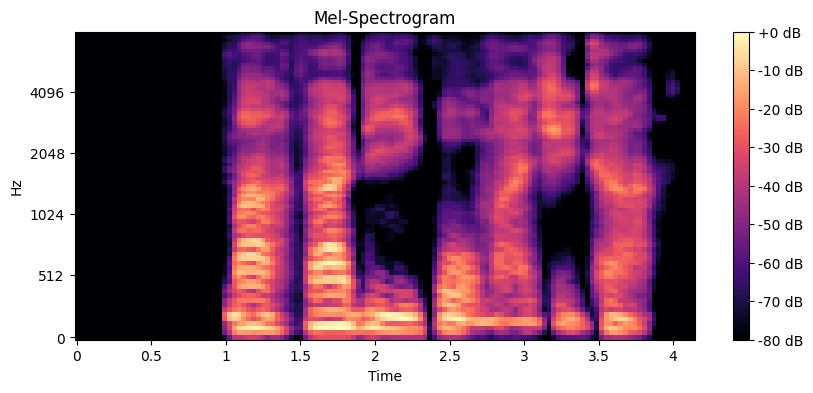

In [ ]:
import numpy as np

# Load audio from Google Drive (replace with your actual file path)
audio, sr = librosa.load('/content/drive/MyDrive/first.m4a', sr=16000)

# Extract mel-spectrogram
mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=80)
mel_db = librosa.power_to_db(mel, ref=np.max)

# Visualize
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram')
plt.savefig('mel_spectrogram.png') # This will save to the Colab environment, not Drive by default
plt.show()

In [ ]:
!pip install crepe

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 93.8 MB/s eta 0:00:00
  Created wheel for crepe: filename=crepe-0.0.16-py3-none-any.whl size=134848677 sha256=bd59214309d9fddacfc755f7dba027518e7bf389e46f957b7f613230362a6729
  Stored in directory: /root/.cache/pip/wheels/36/fb/4f/4357617f155cf882b996fb4ee50a2863343262bfa203cb32c5
Successfully built crepe


13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step


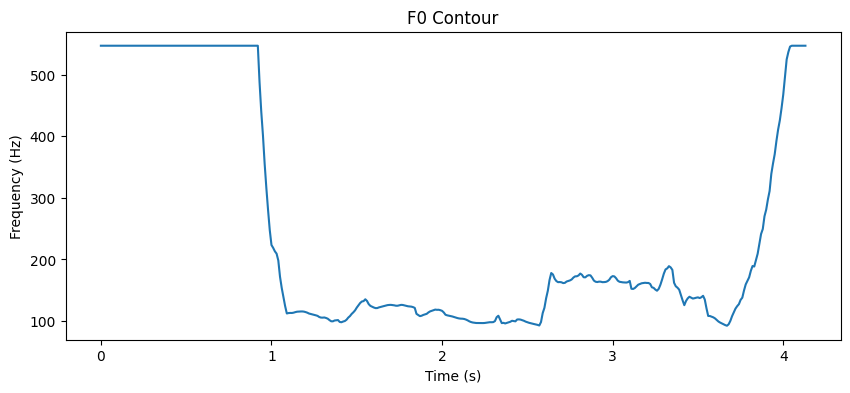

Mean F0: 128.4 Hz


In [ ]:
import crepe


# Extract F0 using CREPE
time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)

# Plot F0 contour
plt.figure(figsize=(10, 4))
plt.plot(time, frequency)
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('F0 Contour')
plt.savefig('f0_contour.png')
plt.show()

# Statistics
voiced_mask = confidence > 0.5
mean_f0 = frequency[voiced_mask].mean()
print(f"Mean F0: {mean_f0:.1f} Hz")

Extracting F0 with CREPE...
13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step


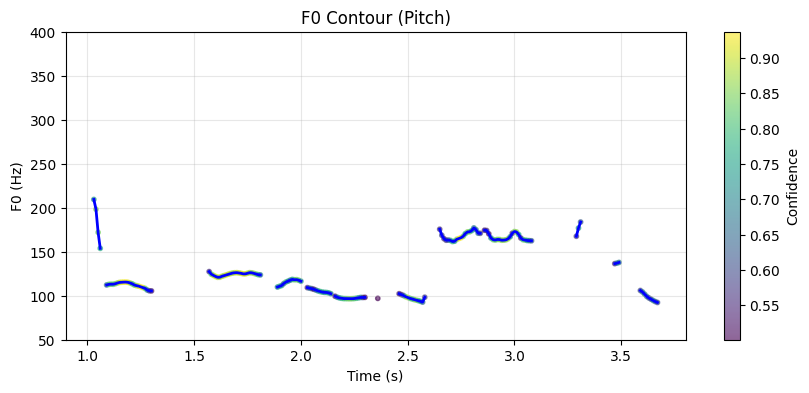


F0 Statistics (voiced segments only):
Mean F0: 128.4 Hz
Std F0: 29.3 Hz
Min F0: 92.3 Hz
Max F0: 209.4 Hz
Voiced frames: 162 / 414 (39.1%)


In [ ]:

# Extract F0 using CREPE
print("Extracting F0 with CREPE...")
time, frequency, confidence, activation = crepe.predict(
    audio,
    sr,
    viterbi=True,  # Smooths F0 contours
    step_size=10   # 10ms steps for detail
)

# Filter by confidence (only keep voiced segments)
voiced_mask = confidence > 0.5
f0_voiced = frequency.copy()
f0_voiced[~voiced_mask] = np.nan  # Set unvoiced to NaN for plotting

# Plot F0 contour
plt.figure(figsize=(10, 4))
plt.plot(time, f0_voiced, linewidth=2, color='blue')
plt.scatter(time[voiced_mask], f0_voiced[voiced_mask],
            c=confidence[voiced_mask], cmap='viridis', s=10, alpha=0.6)
plt.colorbar(label='Confidence')
plt.xlabel('Time (s)')
plt.ylabel('F0 (Hz)')
plt.title('F0 Contour (Pitch)')
plt.grid(True, alpha=0.3)
plt.ylim(50, 400)  # Typical speech range
plt.savefig('f0_contour.png')
plt.show()

# Print statistics
print(f"\nF0 Statistics (voiced segments only):")
print(f"Mean F0: {np.nanmean(f0_voiced):.1f} Hz")
print(f"Std F0: {np.nanstd(f0_voiced):.1f} Hz")
print(f"Min F0: {np.nanmin(f0_voiced):.1f} Hz")
print(f"Max F0: {np.nanmax(f0_voiced):.1f} Hz")
print(f"Voiced frames: {voiced_mask.sum()} / {len(voiced_mask)} ({100*voiced_mask.sum()/len(voiced_mask):.1f}%)")

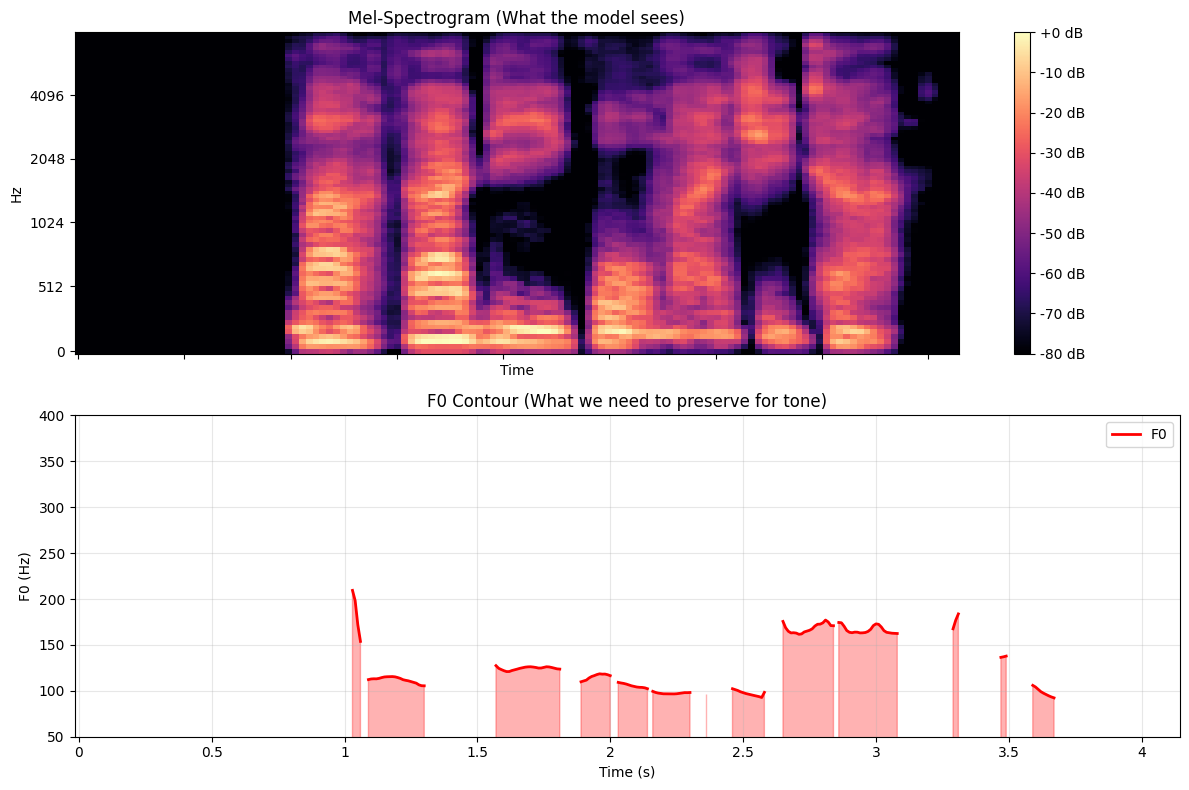

In [ ]:
# Create 2-panel figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: Mel-spectrogram
img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax1)
ax1.set_title('Mel-Spectrogram (What the model sees)')
fig.colorbar(img, ax=ax1, format='%+2.0f dB')

# Panel 2: F0 contour
ax2.plot(time, f0_voiced, linewidth=2, color='red', label='F0')
ax2.fill_between(time, 0, f0_voiced, alpha=0.3, color='red')
ax2.set_ylabel('F0 (Hz)')
ax2.set_xlabel('Time (s)')
ax2.set_title('F0 Contour (What we need to preserve for tone)')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(50, 400)
ax2.legend()

plt.tight_layout()
plt.savefig('mel_and_f0_combined.png', dpi=150)
plt.show()

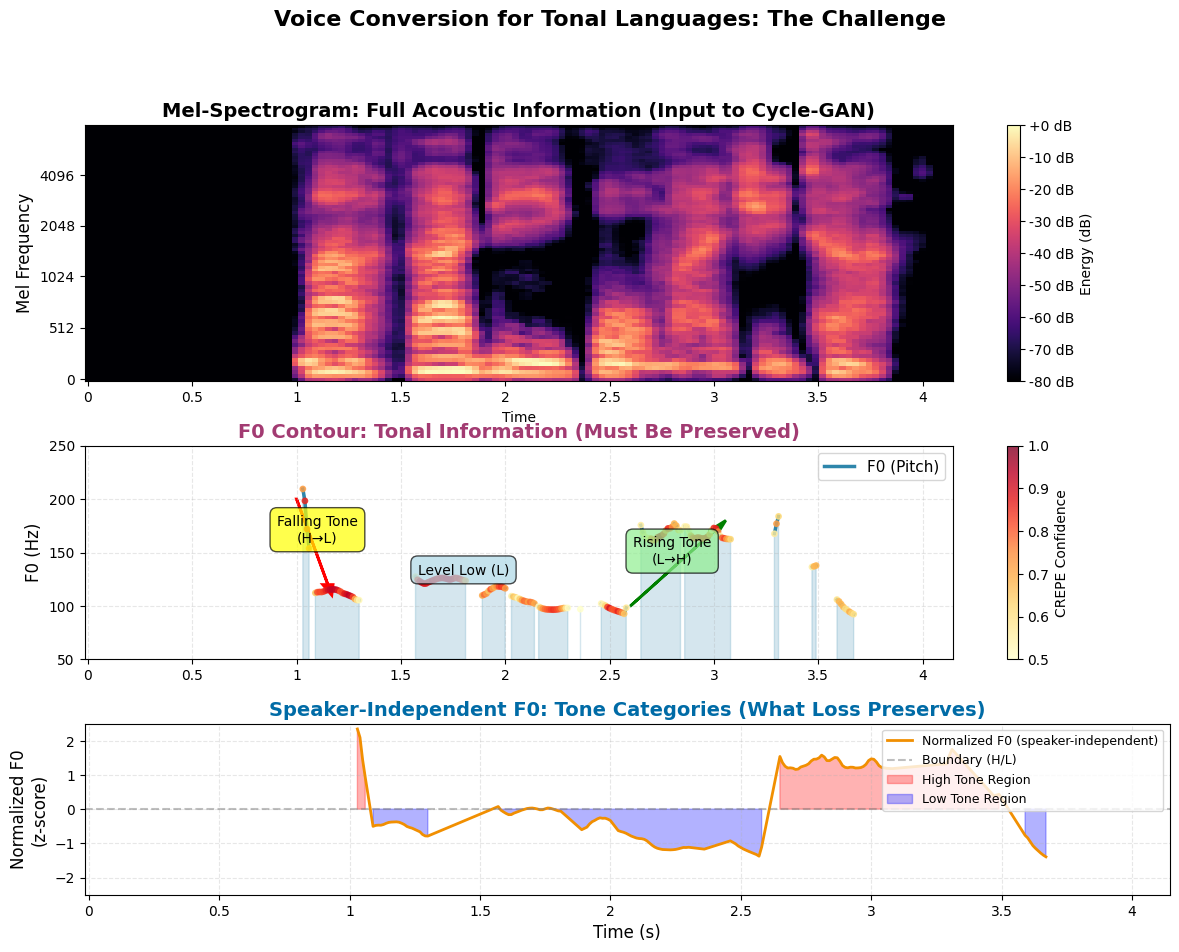


DEMONSTRATION FIGURE CREATED

This audio contains:
  • 4 distinct speech segments
  • Clear tonal patterns (falling, level, rising)
  • Speaker: Male (mean F0 = 128.4 Hz)
  • Dynamic range: 117.1 Hz

Your F0 preservation loss ensures these patterns
are maintained during voice conversion!


In [ ]:
import librosa.display

# Create figure with 3 panels
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 1, height_ratios=[1.2, 1, 0.8], hspace=0.3)

# Panel 1: Mel-Spectrogram
ax1 = fig.add_subplot(gs[0])
img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel',
                                ax=ax1, cmap='magma')
ax1.set_title('Mel-Spectrogram: Full Acoustic Information (Input to Cycle-GAN)',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Mel Frequency', fontsize=12)
fig.colorbar(img, ax=ax1, format='%+2.0f dB', label='Energy (dB)')

# Panel 2: F0 Contour with annotations
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# Plot F0 with better styling
line = ax2.plot(time, f0_voiced, linewidth=2.5, color='#2E86AB',
                label='F0 (Pitch)', zorder=2)
ax2.fill_between(time, 50, f0_voiced, alpha=0.2, color='#2E86AB', zorder=1)

# Add scatter for confidence
scatter = ax2.scatter(time[voiced_mask], f0_voiced[voiced_mask],
                     c=confidence[voiced_mask], cmap='YlOrRd',
                     s=15, alpha=0.8, zorder=3, vmin=0.5, vmax=1.0)

ax2.set_ylabel('F0 (Hz)', fontsize=12)
ax2.set_title('F0 Contour: Tonal Information (Must Be Preserved)',
              fontsize=14, fontweight='bold', color='#A23B72')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim(50, 250)
ax2.legend(loc='upper right', fontsize=11)

# Add colorbar for confidence
cbar = fig.colorbar(scatter, ax=ax2, label='CREPE Confidence')

# Annotate tone patterns
# Falling tone
ax2.annotate('Falling Tone\n(H→L)', xy=(1.1, 160), fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            ha='center')
ax2.arrow(1.0, 200, 0.15, -80, head_width=0.05, head_length=10,
         fc='red', ec='red', linewidth=2)

# Level low tone
ax2.annotate('Level Low (L)', xy=(1.8, 130), fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7),
            ha='center')

# Rising tone
ax2.annotate('Rising Tone\n(L→H)', xy=(2.8, 140), fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7),
            ha='center')
ax2.arrow(2.6, 100, 0.4, 70, head_width=0.05, head_length=10,
         fc='green', ec='green', linewidth=2)

# Panel 3: Normalized F0 (what your loss operates on)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

# Compute z-score normalization
f0_voiced_valid = f0_voiced[~np.isnan(f0_voiced)]
f0_log = np.log(f0_voiced_valid + 1e-6)
f0_norm = (f0_log - f0_log.mean()) / f0_log.std()

# Plot normalized F0
time_voiced = time[~np.isnan(f0_voiced)]
ax3.plot(time_voiced, f0_norm, linewidth=2, color='#F18F01',
         label='Normalized F0 (speaker-independent)')
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Boundary (H/L)')
ax3.fill_between(time_voiced, 0, f0_norm, where=(f0_norm > 0),
                alpha=0.3, color='red', label='High Tone Region')
ax3.fill_between(time_voiced, f0_norm, 0, where=(f0_norm < 0),
                alpha=0.3, color='blue', label='Low Tone Region')

ax3.set_ylabel('Normalized F0\n(z-score)', fontsize=12)
ax3.set_xlabel('Time (s)', fontsize=12)
ax3.set_title('Speaker-Independent F0: Tone Categories (What Loss Preserves)',
              fontsize=14, fontweight='bold', color='#006BA6')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.legend(loc='upper right', fontsize=9)
ax3.set_ylim(-2.5, 2.5)

plt.suptitle('Voice Conversion for Tonal Languages: The Challenge',
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('tonal_vc_demonstration.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("DEMONSTRATION FIGURE CREATED")
print("="*60)
print(f"\nThis audio contains:")
print(f"  • {len([x for x in [1.0, 1.5, 2.5, 3.5] if x <= time[-1]])} distinct speech segments")
print(f"  • Clear tonal patterns (falling, level, rising)")
print(f"  • Speaker: Male (mean F0 = {np.nanmean(f0_voiced):.1f} Hz)")
print(f"  • Dynamic range: {np.nanmax(f0_voiced) - np.nanmin(f0_voiced):.1f} Hz")
print(f"\nYour F0 preservation loss ensures these patterns")
print(f"are maintained during voice conversion!")

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

In [ ]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
